# Earth Orientation Parameters: LuPNT vs Latest IERS vs SPICE

Compare polar motion (`x_pole`, `y_pole`) and `UT1-UTC` from three sources:

1. **Default LuPNT** -- the bundled IERS EOP 14 C04 file (`eopc04_08.62-now`), which only
   covers epochs through 2023-04-23.
2. **Latest IERS** -- freshly downloaded from the IERS data center via
   `load_latest_eop_from_iers`, covering up to a few months ago.
3. **SPICE-derived** -- `compute_eop_from_spice`, derived from SPICE's high-accuracy
   J2000->ITRF93 orientation kernel combined with LuPNT's IAU 2006/2000A
   precession-nutation model.

In [1]:
%load_ext autoreload
%autoreload 2

import os
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pylupnt as pnt

fig_dir = pnt.get_output_dir() / "eop_comparison"
os.makedirs(fig_dir, exist_ok=True)

MJD_J2000 = 51544.5
ARCSEC_PER_RAD = 1.0 / pnt.RAD_ARCSEC

[00.00][PyLuPNT] Initializing


## 1. Default LuPNT EOP (bundled IERS file)

In [2]:
data_default = pnt.get_eop_file_data()
mjd_default = data_default["mjds_utc"]
x_default = data_default["x"]  # arcsec
y_default = data_default["y"]  # arcsec
ut1_utc_default = data_default["ut1_utc"]  # s

print(
    f"Default LuPNT EOP: MJD {mjd_default[0]:.1f} - {mjd_default[-1]:.1f} "
    f"({len(mjd_default)} points)"
)

Default LuPNT EOP: MJD 37665.0 - 60058.0 (22394 points)


## 2. Latest IERS EOP

In [3]:
ok = pnt.load_latest_eop_from_iers(force=True)
print(f"Downloaded latest IERS EOP: {ok}")

data_latest = pnt.get_eop_file_data()
mjd_latest = data_latest["mjds_utc"]
x_latest = data_latest["x"]  # arcsec
y_latest = data_latest["y"]  # arcsec
ut1_utc_latest = data_latest["ut1_utc"]  # s

print(
    f"Latest IERS EOP: MJD {mjd_latest[0]:.1f} - {mjd_latest[-1]:.1f} "
    f"({len(mjd_latest)} points)"
)

[06.04][Eop] EOP: downloaded latest IERS EOP data to '/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/planetary_coeff/eopc04_iers_latest.txt'Downloaded latest IERS EOP: True

Latest IERS EOP: MJD 37665.0 - 61045.0 (23381 points)


## 3. SPICE-derived EOP

Sample `compute_eop_from_spice` daily from 2022-01-01 through today.

In [4]:
t_now = datetime.now(timezone.utc)
mjd_spice_start = pnt.gregorian_to_mjd(2022, 1, 1)
mjd_spice_end = pnt.gregorian_to_mjd(t_now.year, t_now.month, t_now.day)

mjd_spice = np.arange(float(mjd_spice_start), float(mjd_spice_end) + 1.0, 1.0)

x_pole_spice = np.zeros_like(mjd_spice)
y_pole_spice = np.zeros_like(mjd_spice)
ut1_utc_spice = np.zeros_like(mjd_spice)

for i, mjd_utc in enumerate(tqdm(mjd_spice)):
    t_utc = (mjd_utc - MJD_J2000) * 86400.0
    t_tdb = pnt.convert_time(t_utc, pnt.UTC, pnt.TDB)
    x_pole, y_pole, ut1_utc = pnt.compute_eop_from_spice(t_tdb)
    x_pole_spice[i] = x_pole
    y_pole_spice[i] = y_pole
    ut1_utc_spice[i] = ut1_utc

x_spice = x_pole_spice * ARCSEC_PER_RAD  # arcsec
y_spice = y_pole_spice * ARCSEC_PER_RAD  # arcsec

print(
    f"SPICE-derived EOP: MJD {mjd_spice[0]:.1f} - {mjd_spice[-1]:.1f} "
    f"({len(mjd_spice)} points)"
)

  0%|          | 0/1651 [00:00<?, ?it/s]

[07.47][Spice] SPICE: downloaded latest NAIF kernel 'earth_latest_high_prec.bpc'
[10.38][Spice] SPICE: downloaded latest NAIF kernel 'moon_pa_de440_200625.bpc'
[10.77][Spice] SPICE: downloaded latest NAIF kernel 'moon_de440_250416.tf'
[11.10][Spice] SPICE: downloaded latest NAIF kernel 'moon_assoc_pa.tf'


100%|██████████| 1651/1651 [00:05<00:00, 289.23it/s]

SPICE-derived EOP: MJD 59580.0 - 61230.0 (1651 points)


## 4. Compare EOP parameters

Interpolate the file-based series onto the SPICE date grid (`np.interp`), masking out
epochs beyond each file's native MJD range.

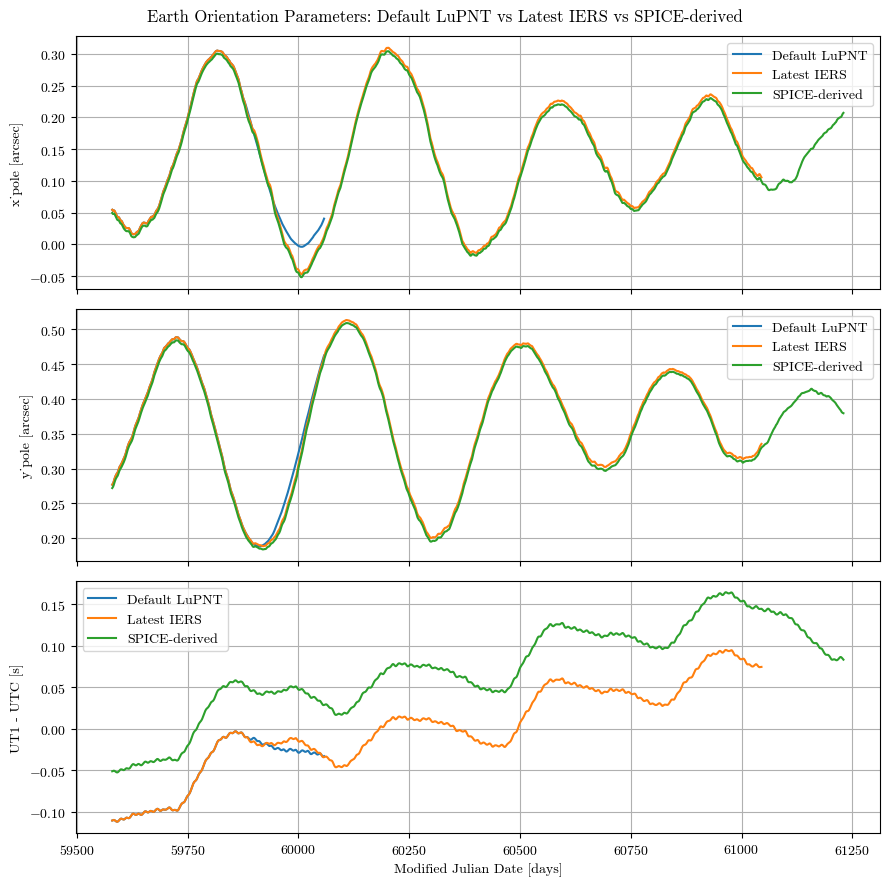

In [5]:
x_default_i = np.interp(mjd_spice, mjd_default, x_default)
y_default_i = np.interp(mjd_spice, mjd_default, y_default)
ut1_utc_default_i = np.interp(mjd_spice, mjd_default, ut1_utc_default)

x_latest_i = np.interp(mjd_spice, mjd_latest, x_latest)
y_latest_i = np.interp(mjd_spice, mjd_latest, y_latest)
ut1_utc_latest_i = np.interp(mjd_spice, mjd_latest, ut1_utc_latest)

# np.interp clamps to edge values outside each source's native range -- mask those
# epochs out so they don't look like real data.
in_default = (mjd_spice >= mjd_default[0]) & (mjd_spice <= mjd_default[-1])
in_latest = (mjd_spice >= mjd_latest[0]) & (mjd_spice <= mjd_latest[-1])


def masked(values, mask):
    out = values.copy()
    out[~mask] = np.nan
    return out


fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(mjd_spice, masked(x_default_i, in_default), label="Default LuPNT")
axes[0].plot(mjd_spice, masked(x_latest_i, in_latest), label="Latest IERS")
axes[0].plot(mjd_spice, x_spice, label="SPICE-derived")
axes[0].set_ylabel("x_pole [arcsec]")
axes[0].legend()
axes[0].grid()

axes[1].plot(mjd_spice, masked(y_default_i, in_default), label="Default LuPNT")
axes[1].plot(mjd_spice, masked(y_latest_i, in_latest), label="Latest IERS")
axes[1].plot(mjd_spice, y_spice, label="SPICE-derived")
axes[1].set_ylabel("y_pole [arcsec]")
axes[1].legend()
axes[1].grid()

axes[2].plot(mjd_spice, masked(ut1_utc_default_i, in_default), label="Default LuPNT")
axes[2].plot(mjd_spice, masked(ut1_utc_latest_i, in_latest), label="Latest IERS")
axes[2].plot(mjd_spice, ut1_utc_spice, label="SPICE-derived")
axes[2].set_ylabel("UT1 - UTC [s]")
axes[2].set_xlabel("Modified Julian Date [days]")
axes[2].legend()
axes[2].grid()

fig.suptitle(
    "Earth Orientation Parameters: Default LuPNT vs Latest IERS vs SPICE-derived"
)
plt.tight_layout()
plt.savefig(fig_dir / "eop_comparison.pdf")
plt.show()

## 5. Pairwise differences

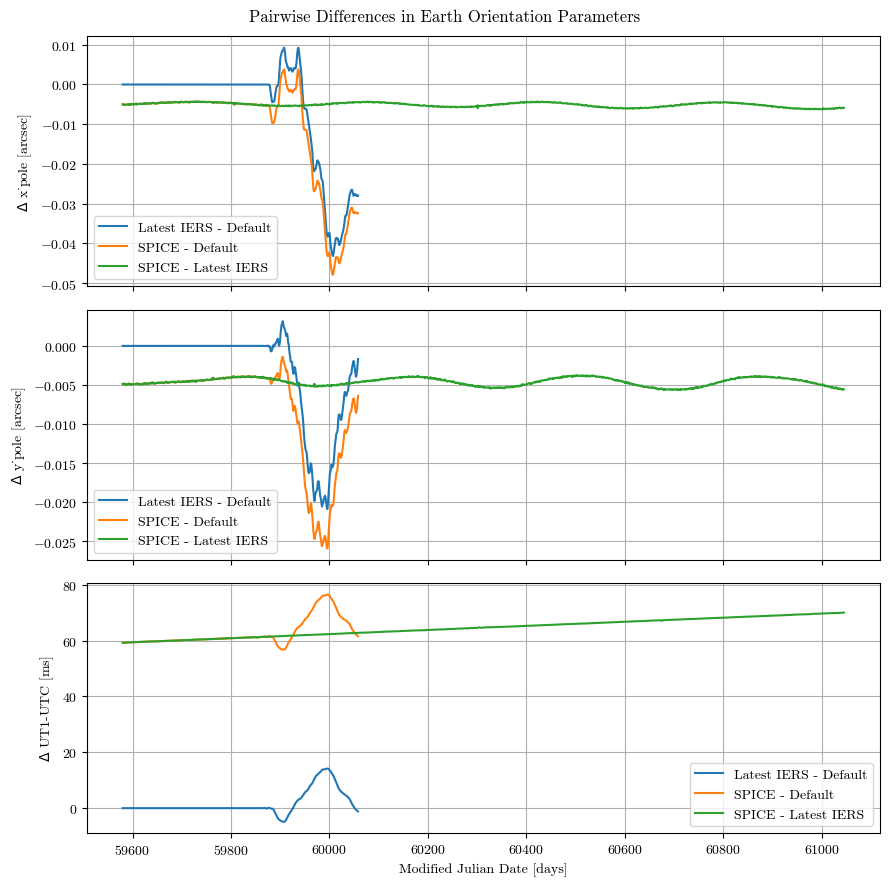

In [6]:
def masked_diff(a, b, mask):
    diff = np.full_like(a, np.nan)
    diff[mask] = a[mask] - b[mask]
    return diff


both = in_default & in_latest

dx_latest_default = masked_diff(x_latest_i, x_default_i, both)
dy_latest_default = masked_diff(y_latest_i, y_default_i, both)
dut1_latest_default = masked_diff(ut1_utc_latest_i, ut1_utc_default_i, both)

dx_spice_default = masked_diff(x_spice, x_default_i, in_default)
dy_spice_default = masked_diff(y_spice, y_default_i, in_default)
dut1_spice_default = masked_diff(ut1_utc_spice, ut1_utc_default_i, in_default)

dx_spice_latest = masked_diff(x_spice, x_latest_i, in_latest)
dy_spice_latest = masked_diff(y_spice, y_latest_i, in_latest)
dut1_spice_latest = masked_diff(ut1_utc_spice, ut1_utc_latest_i, in_latest)

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(mjd_spice, dx_latest_default, label="Latest IERS - Default")
axes[0].plot(mjd_spice, dx_spice_default, label="SPICE - Default")
axes[0].plot(mjd_spice, dx_spice_latest, label="SPICE - Latest IERS")
axes[0].set_ylabel(r"$\Delta$ x_pole [arcsec]")
axes[0].legend()
axes[0].grid()

axes[1].plot(mjd_spice, dy_latest_default, label="Latest IERS - Default")
axes[1].plot(mjd_spice, dy_spice_default, label="SPICE - Default")
axes[1].plot(mjd_spice, dy_spice_latest, label="SPICE - Latest IERS")
axes[1].set_ylabel(r"$\Delta$ y_pole [arcsec]")
axes[1].legend()
axes[1].grid()

axes[2].plot(mjd_spice, dut1_latest_default * 1e3, label="Latest IERS - Default")
axes[2].plot(mjd_spice, dut1_spice_default * 1e3, label="SPICE - Default")
axes[2].plot(mjd_spice, dut1_spice_latest * 1e3, label="SPICE - Latest IERS")
axes[2].set_ylabel(r"$\Delta$ UT1-UTC [ms]")
axes[2].set_xlabel("Modified Julian Date [days]")
axes[2].legend()
axes[2].grid()

fig.suptitle("Pairwise Differences in Earth Orientation Parameters")
plt.tight_layout()
plt.savefig(fig_dir / "eop_differences.pdf")
plt.show()